---

<table style="width:100%">
  <tr>
    <th>
        <div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> Конспект лекцій з предмету: </p>
<p style="text-align: center;"><b><h2>"Електронні прилади та мікроелектроніка"</h2></b></p>
<p style="text-align: center;"> Національний університет "Чернігівська політехніка"</p>
<p style="text-align: center;"><b>Кафедра:</b> Радіотехніки та відеоінформаційних систем (РТВС)</p>
<hr/>
<p style="text-align: center;"><b>Теми частини:</b></p>
<ul style="text-align: left;">
  <li>Біполярні транзистори: структура, режими, схеми включення</li>
  <li>Статичні та частотні характеристики біполярного транзистора</li>
  <li>Пробій та температурна залежність підсилення БТ</li>
  <li>Польові транзистори з керуючим p-n переходом (JFET)</li>
  <li>МДН-транзистори з індукованим каналом (MOSFET)</li>
  <li>Частотні властивості та імпульсна робота польових транзисторів</li>
</ul>
</div>
    </th>
    <th>
<div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> <b>Викладач:</b> </p>
<img src="Teacher.jpg" width="150" style="border-radius: 50%; display: block; margin: 10px auto;"/>
<p style="text-align: center;"><b>Пахалюк Богдан Петрович</b></p>
<p style="text-align: center;">Доктор філософії</p>
<p style="text-align: center;">Кафедра РТВС</p>
<hr/>
<p style="text-align: center; font-size: 0.9em;">Частина 2 з 3: Біполярні та польові транзистори</p>
</div>
    </th>
  </tr>
</table>

---


<p style="text-align: center;"><b>Зміст</b></p>

* [Біполярні транзистори. Різновиди, режими роботи, принцип дії](#bjt-basics)
* [Основні схеми включення біполярних транзисторів](#bjt-configs)
* [Статичні характеристики транзистора в схемі зі спільним емітером](#bjt-ce-characteristics)
* [Пробій в біполярному транзисторі](#bjt-breakdown)
* [Залежність коефіцієнта підсилення БТ від режиму роботи](#bjt-gain-dependence)
* [Частотні характеристики біполярного транзистора](#bjt-frequency)
    * [✅ Самоперевірка: біполярні транзистори](#bjt-selfcheck)
* [Польові транзистори з керуючим p-n переходом (JFET)](#jfet-basics)
* [Статичні характеристики JFET](#jfet-characteristics)
* [МДН-транзистор з індукованим каналом: принцип дії](#mosfet-enhancement)
* [Статичні характеристики МДН-транзистора з індукованим каналом](#mosfet-characteristics)
* [Частотні властивості польових транзисторів](#fet-frequency)
* [Робота польового транзистора на імпульс](#fet-pulse)
    * [✅ Самоперевірка: польові транзистори](#fet-selfcheck)
* [Підсумок: БТ проти ПТ](#bjt-vs-fet-summary)

---


In [1]:
import numpy as np
import sympy as smp
import matplotlib.pyplot as plt
from matplotlib.widgets import Cursor
from ipywidgets import interact, interactive, fixed, HBox, VBox, Output
import ipywidgets as widgets
from IPython.display import display, HTML, Markdown
%matplotlib inline

import math
from engineering_notation import EngNumber

import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging()
from PySpice.Doc.ExampleTools import find_libraries
from PySpice.Probe.Plot import plot
from PySpice.Spice.Library import SpiceLibrary
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *

try:
    import schemdraw
    import schemdraw.elements as elm
    SCHEMDRAW_AVAILABLE = True
except ImportError:
    SCHEMDRAW_AVAILABLE = False
    print('schemdraw не встановлено (pip install schemdraw)')

plt.rcParams.update({
    'figure.figsize': (8, 4), 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.labelsize': 12, 'axes.titlesize': 13, 'lines.linewidth': 2,
    'font.size': 11,
})


/home/bp/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


### 🎯 Мета вивчення розділу: Біполярні транзистори

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Пояснювати структуру та принцип дії NPN і PNP транзисторів
> - Розрізняти режими роботи транзистора за станом переходів (активний, насичення, відсічка, інверсний)
> - Описувати фізику інжекції, дифузії та екстракції неосновних носіїв у базі
> - Пояснювати роль тонкої та слаболегованої бази для передачі струму емітера в колектор

</div>


### 📖 Ключові поняття

| Поняття | Визначення |
|---------|-----------|
| **Біполярний транзистор (БТ)** | Прилад з двома p-n переходами і трьома областями (емітер, база, колектор), у якому струм переносять носії *обох* знаків |
| **Емітер (Е)** | Сильнолегована область, що інжектує неосновні носії в базу |
| **База (Б)** | Тонка, слаболегована область; більшість інжектованих носіїв проходить її транзитом |
| **Колектор (К)** | Область, що збирає (екстрагує) носії, які пройшли базу |
| **Коефіцієнт передачі струму емітера $\alpha$** | $\alpha = I_к/I_е \approx 0.98$–$0.998$ |
| **Коефіцієнт підсилення струму бази $\beta$ (h21e)** | $\beta = I_к/I_б = \alpha/(1-\alpha)$, зазвичай 50–500 |

---

# Біполярні транзистори. Різновиди, режими роботи та принцип дії <a class="anchor" id="bjt-basics"></a>

**Біполярний транзистор** — напівпровідниковий прилад із двома взаємодіючими p-n переходами, утвореними трьома почергово легованими областями: **емітером (Е)**, **базою (Б)** і **колектором (К)**. Залежно від порядку легування розрізняють структури **n-p-n** та **p-n-p** (звідси й «біполярний» — переносять заряд і електрони, і дірки).

Головна конструктивна особливість — база настільки **тонка** (одиниці мікрометрів) і **слаболегована**, що переважна більшість носіїв, інжектованих емітером, не встигає рекомбінувати і дифундує наскрізь до колекторного переходу, де витягується його полем. Саме тому струм колектора майже дорівнює струму емітера, а слабкий струм бази керує значно більшим струмом колектора — в цьому і полягає **підсилювальна дія** транзистора.

**Фізика роботи (на прикладі n-p-n, активний режим):**
1. Перехід емітер–база зміщений у **прямому** напрямку → потенціальний бар'єр знижується, і емітер **інжектує** електрони в базу (а база — дірки в емітер, але через сильне легування емітера цей зустрічний потік дірок значно слабший).
2. Інжектовані електрони — неосновні носії в p-базі — **дифундують** через базу до колекторного переходу під дією градієнта концентрації.
3. Перехід база–колектор зміщений у **зворотному** напрямку, тому його поле **екстрагує** (втягує) електрони, що дійшли до межі переходу, у колектор.
4. Лише мала частка електронів встигає рекомбінувати з дірками бази — цей рекомбінаційний струм і формує струм бази $I_б$.

Основна рівність токів транзистора: $I_е = I_б + I_к$.

**Різновиди біполярних транзисторів:**
- за структурою: **n-p-n** (основні носії в базі — електрони, найпоширеніші через вищу рухливість електронів і, відповідно, кращу швидкодію) та **p-n-p**;
- за технологією виготовлення: епітаксійно-планарні, дифузійні, мезаплощинні;
- за потужністю: малопотужні (< 0.3 Вт), середньої потужності, потужні (> 1.5 Вт);
- за частотними властивостями: низькочастотні, високочастотні, надвисокочастотні (СВЧ);
- за призначенням: універсальні, ключові (комутаційні), НВЧ, лавинні, композитні (Дарлінгтона).


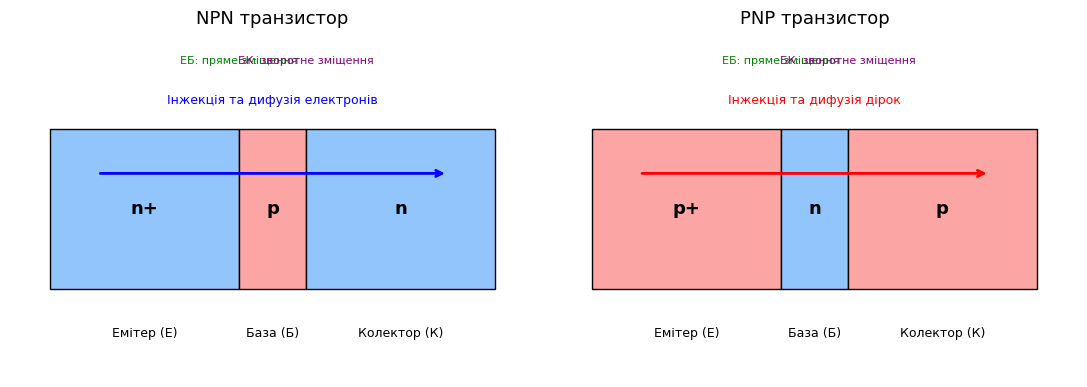

In [2]:
def draw_bjt_structure():
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    configs = [
        ('npn', [('n+', '#93c5fd'), ('p', '#fca5a5'), ('n', '#93c5fd')], 'NPN транзистор', 'blue', 'електронів'),
        ('pnp', [('p+', '#fca5a5'), ('n', '#93c5fd'), ('p', '#fca5a5')], 'PNP транзистор', 'red', 'дірок'),
    ]
    labels = ['Емітер (E)', 'База (Б)', 'Колектор (К)']
    widths = [1.4, 0.5, 1.4]
    for ax, (kind, regions, title, color, carrier) in zip(axes, configs):
        x = 0.0
        for (reg, fc), w, lab in zip(regions, widths, labels):
            ax.add_patch(plt.Rectangle((x, 0), w, 1, facecolor=fc, edgecolor='k'))
            ax.text(x + w / 2, 0.5, reg, ha='center', va='center', fontsize=13, fontweight='bold')
            ax.text(x + w / 2, -0.28, lab, ha='center', va='center', fontsize=9)
            x += w
        ax.annotate('', xy=(x - 0.35, 0.72), xytext=(0.35, 0.72),
                    arrowprops=dict(arrowstyle='->', color=color, lw=2))
        ax.text(x / 2, 1.15, f'Інжекція та дифузія {carrier}', color=color, fontsize=9, ha='center')
        ax.text(widths[0], 1.4, 'ЕБ: пряме зміщення', fontsize=8, ha='center', color='green')
        ax.text(widths[0] + widths[1], 1.4, 'БК: зворотне зміщення', fontsize=8, ha='center', color='purple')
        ax.set_xlim(-0.3, x + 0.3)
        ax.set_ylim(-0.55, 1.6)
        ax.axis('off')
        ax.set_title(title)
    plt.tight_layout()
    plt.show()

draw_bjt_structure()


**Режими роботи транзистора** визначаються полярністю зміщення обох переходів:

| Режим | Перехід Е–Б | Перехід Б–К | Застосування |
|-------|-------------|-------------|--------------|
| **Активний нормальний** | Прямий | Зворотний | Аналогове підсилення сигналів |
| **Насичення** | Прямий | Прямий | Ключ у замкненому стані ("увімкнено") |
| **Відсічка** | Зворотний | Зворотний | Ключ у розімкненому стані ("вимкнено") |
| **Інверсний активний** | Зворотний | Прямий | Рідко; емітер і колектор міняються ролями, $\beta$ значно менший |

У **насиченні** обидва переходи відкриті, тому в базі накопичується надлишковий заряд неосновних носіїв, а напруга $U_{КЕ,нас} \approx 0.1$–$0.3$ В — транзистор поводиться майже як замкнений ключ. У **відсічці** обидва переходи закриті, через транзистор тече лише малий тепловий струм — ключ розімкнений. Ключовий (перемикальний) режим (чергування насичення і відсічки) — основа цифрової та імпульсної електроніки, тоді як **активний режим** використовують для лінійного підсилення.

### 💡 Цікаво знати

<div style="background-color: #eff6ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #2563eb; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Перший працюючий транзистор — **точковий (point-contact) транзистор** — створили **Джон Бардін** і **Волтер Браттейн** у грудні 1947 р. в Bell Labs, а вже в 1948 р. **Вільям Шоклі** розробив набагато практичнішу **біполярну площинну (junction) структуру** n-p-n/p-n-p, яка й стала основою всієї подальшої напівпровідникової електроніки. У 1956 р. усі троє отримали Нобелівську премію з фізики "за дослідження напівпровідників і відкриття транзисторного ефекту".

</div>


## Основні схеми включення біполярних транзисторів <a class="anchor" id="bjt-configs"></a>

Транзистор — трипольсний елемент, а підсилювальний каскад — двопортова (чотириполюсникова) схема, тому один із виводів транзистора обов'язково є **спільним** для вхідного та вихідного кіл. Звідси три базові схеми включення.

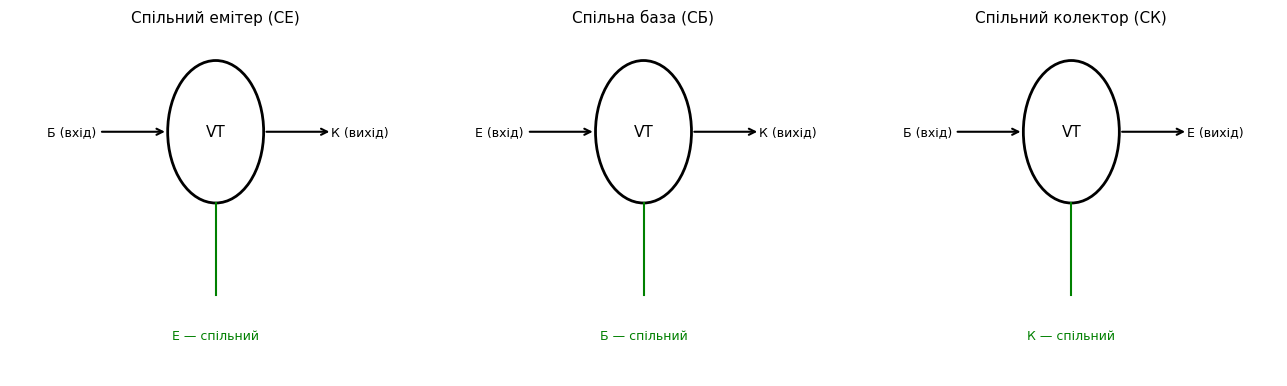

In [3]:
def draw_configs():
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    configs = [
        ('Спільний емітер (СЕ)', 'Б (вхід)', 'К (вихід)', 'Е — спільний'),
        ('Спільна база (СБ)', 'Е (вхід)', 'К (вихід)', 'Б — спільний'),
        ('Спільний колектор (СК)', 'Б (вхід)', 'Е (вихід)', 'К — спільний'),
    ]
    for ax, (title, inp, outp, common) in zip(axes, configs):
        ax.add_patch(plt.Circle((0.5, 0.5), 0.35, fill=False, lw=2))
        ax.text(0.5, 0.5, 'VT', ha='center', va='center', fontsize=11)
        ax.annotate('', xy=(0.15, 0.5), xytext=(-0.35, 0.5), arrowprops=dict(arrowstyle='->', lw=1.5))
        ax.text(-0.55, 0.5, inp, ha='center', va='center', fontsize=9)
        ax.annotate('', xy=(1.35, 0.5), xytext=(0.85, 0.5), arrowprops=dict(arrowstyle='->', lw=1.5))
        ax.text(1.55, 0.5, outp, ha='center', va='center', fontsize=9)
        ax.plot([0.5, 0.5], [0.15, -0.3], 'g-', lw=1.5)
        ax.text(0.5, -0.5, common, ha='center', va='center', fontsize=9, color='green')
        ax.set_xlim(-1.0, 2.0)
        ax.set_ylim(-0.7, 1.0)
        ax.axis('off')
        ax.set_title(title, fontsize=11)
    plt.tight_layout()
    plt.show()

draw_configs()


| Параметр | СЕ | СБ | СК (емітерний повторювач) |
|----------|-----|-----|-----|
| Підсилення струму $K_I$ | Велике ($\approx \beta$) | $\approx 1$ (трохи менше) | Велике ($\approx \beta$) |
| Підсилення напруги $K_U$ | Велике | Велике | $\approx 1$ (трохи менше) |
| Підсилення потужності | Найбільше | Середнє | Середнє |
| Вхідний опір $R_{вх}$ | Середній (сотні Ом – кОм) | Малий (одиниці – десятки Ом) | Великий (десятки – сотні кОм) |
| Вихідний опір $R_{вих}$ | Середній–великий | Дуже великий | Малий (одиниці – десятки Ом) |
| Інверсія фази вихідної напруги | Так (180°) | Ні | Ні |
| Типове застосування | Універсальний підсилювач напруги/потужності | Широкосмугові та НВЧ каскади, узгодження з низьким $R_{вх}$ | Буфер, узгодження опорів (повторювач) |

Схема **СЕ** — найпоширеніша, оскільки єдина з-поміж трьох одночасно підсилює і струм, і напругу (а отже, дає максимальне підсилення за потужністю), тому саме її характеристики розглядають найдетальніше (наступний розділ).

### 🎯 Мета вивчення розділу: Статичні характеристики БТ

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Пояснювати фізичний зміст вхідної та вихідної статичних характеристик схеми СЕ
> - Виділяти на вихідних характеристиках області відсічки, активну область і область насичення
> - Будувати та застосовувати навантажувальну пряму для визначення робочої точки

</div>


## Статичні характеристики транзистора в схемі зі спільним емітером <a class="anchor" id="bjt-ce-characteristics"></a>

Статичні (вольт-амперні) характеристики БТ у схемі СЕ — це залежності струмів від напруг при фіксованих значеннях третьої змінної, зняті при постійних (не змінних у часі) режимах.

**Вхідна характеристика** $I_б = f(U_{бе})$ при $U_{ке} = \text{const}$ — за формою нагадує пряму гілку ВАХ звичайного діода (перехід база–емітер зміщений прямо), і зі зростанням $U_{ке}$ трохи зсувається праворуч (ефект Ерлі — розширення області просторового заряду колекторного переходу трохи "витягує" носії з бази, зменшуючи ефективну товщину бази).

**Вихідна характеристика** $I_к = f(U_{ке})$ при $I_б = \text{const}$ — сімейство кривих для різних струмів бази. На ній виділяють три характерні області:
- **область відсічки** — під нижньою кривою ($I_б \approx 0$), обидва переходи закриті, $I_к \approx I_{кео}$ (малий тепловий струм);
- **активна область** — криві майже горизонтальні (пологі, з невеликим нахилом через ефект Ерлі), $I_к \approx \beta I_б$ практично не залежить від $U_{ке}$;
- **область насичення** — при малих $U_{ке}$ (менших за $U_{ке,нас} \approx 0.2$–$0.3$ В) криві різко зростають, обидва переходи відкриті, і $I_к$ вже не керується лише $I_б$, а обмежується зовнішнім колом (навантаженням).

**Навантажувальна пряма** будується на сімействі вихідних характеристик за рівнянням кола живлення $E_к = I_к R_к + U_{ке}$, тобто $I_к = (E_к - U_{ке})/R_к$ — пряма лінія від точки $(0, E_к/R_к)$ до точки $(E_к, 0)$. Перетин навантажувальної прямої з кривою заданого $I_б$ визначає **робочу точку** транзистора (значення $I_к$ і $U_{ке}$ у спокої).

2026-09-21 10:49:28,295 - PySpice.Spice.NgSpice.Shared.NgSpiceShared._init_ngspice - WARNING - Unsupported Ngspice version 42


2026-09-21 10:49:28,333 - PySpice.Spice.NgSpice.Shared.NgSpiceShared._send_char - WARNING - Using SPARSE 1.3 as Direct Linear Solver


2026-09-21 10:49:28,361 - PySpice.Spice.NgSpice.Shared.NgSpiceShared._send_char - WARNING - Using SPARSE 1.3 as Direct Linear Solver


2026-09-21 10:49:28,398 - PySpice.Spice.NgSpice.Shared.NgSpiceShared._send_char - WARNING - Using SPARSE 1.3 as Direct Linear Solver


2026-09-21 10:49:28,422 - PySpice.Spice.NgSpice.Shared.NgSpiceShared._send_char - WARNING - Using SPARSE 1.3 as Direct Linear Solver


2026-09-21 10:49:28,445 - PySpice.Spice.NgSpice.Shared.NgSpiceShared._send_char - WARNING - Using SPARSE 1.3 as Direct Linear Solver


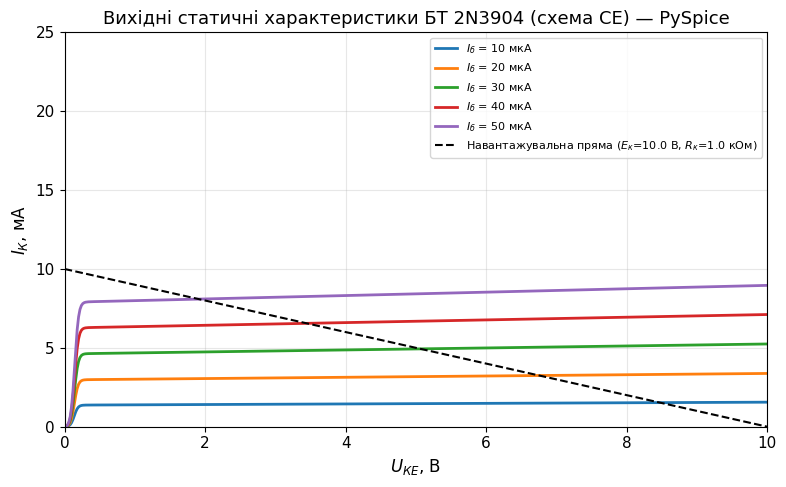

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
for ib_uA in [10, 20, 30, 40, 50]:
    circuit = Circuit('BJT CE output characteristics')
    circuit.include('2n3904.lib')
    circuit.I('B', circuit.gnd, 'b', ib_uA @ u_uA)
    circuit.V('CE', 'c', circuit.gnd, 0 @ u_V)
    circuit.BJT(1, 'c', 'b', circuit.gnd, model='Q2N3904')
    simulator = circuit.simulator(temperature=25, nominal_temperature=25)
    analysis = simulator.dc(VCE=slice(0, 10, 0.02))
    vce = np.array(analysis['c'])
    ic = -np.array(analysis['VCE']) * 1000
    ax.plot(vce, ic, label=f'$I_б$ = {ib_uA} мкА')

# навантажувальна пряма: Eк = 10 В, Rк = 1 кОм
Ek, Rk = 10.0, 1.0
vce_line = np.array([0, Ek])
ic_line = (Ek - vce_line) / Rk
ax.plot(vce_line, ic_line, 'k--', lw=1.5, label=f'Навантажувальна пряма ($E_к$={Ek} В, $R_к$={Rk} кОм)')

ax.set_xlabel('$U_{КЕ}$, В')
ax.set_ylabel('$I_К$, мА')
ax.set_title('Вихідні статичні характеристики БТ 2N3904 (схема СЕ) — PySpice')
ax.set_xlim(0, 10)
ax.set_ylim(0, 25)
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()


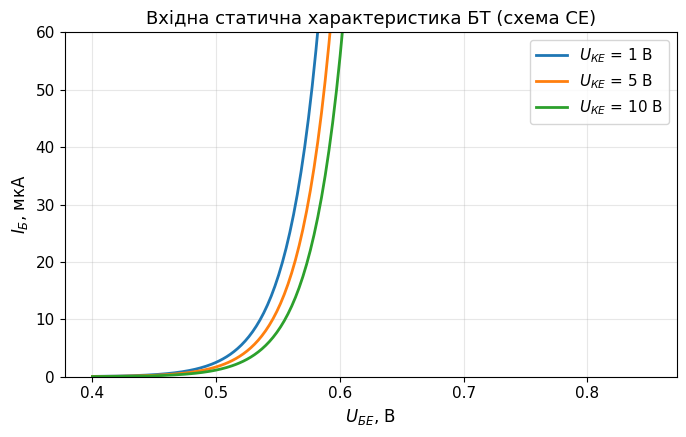

In [5]:
# Вхідна характеристика Iб = f(Uбе) при кількох Uке — модель ідеального діода бази-емітера
Ube = np.linspace(0.4, 0.85, 300)
Is = 1e-14
Vt = 0.02585
fig, ax = plt.subplots(figsize=(7, 4.5))
for uke, shift in zip([1, 5, 10], [0, 0.01, 0.02]):
    Ib = Is * (np.exp((Ube - shift) / Vt) - 1) * 1e6  # мкА
    ax.plot(Ube, Ib, label=f'$U_{{КЕ}}$ = {uke} В')
ax.set_xlabel('$U_{БЕ}$, В')
ax.set_ylabel('$I_Б$, мкА')
ax.set_ylim(0, 60)
ax.set_title('Вхідна статична характеристика БТ (схема СЕ)')
ax.legend()
plt.tight_layout()
plt.show()


### 📌 Підсумок: Області вихідної характеристики СЕ

<div style="background-color: #f0fdf4; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #16a34a; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">


| Область | Стан переходів | Ознака на графіку |
|---------|----------------|--------------------|
| Відсічка | ЕБ закритий, БК закритий | $I_к \approx 0$, нижня крива |
| Активна | ЕБ відкритий, БК закритий | Пологі horizontal-подібні криві, $I_к = \beta I_б$ |
| Насичення | ЕБ відкритий, БК відкритий | Крутий підйом при малих $U_{КЕ}$ |


</div>


## Пробій в біполярному транзисторі <a class="anchor" id="bjt-breakdown"></a>

Як і звичайний p-n перехід, колекторний перехід транзистора може пробитися при перевищенні гранично допустимої зворотної напруги. Розрізняють кілька видів пробою.

**Лавинний (первинний) пробій колекторного переходу.** При зростанні $U_{КБ}$ (або $U_{КЕ}$) неосновні носії, що перетинають область просторового заряду колекторного переходу, набувають достатньої енергії для ударної іонізації — розвивається лавинне розмноження носіїв, яке характеризують коефіцієнтом лавинного множення
$$M = \dfrac{1}{1-\left(\dfrac{U_{КЕ}}{BV_{КЕО}}\right)^n}, \qquad n \approx 2\text{–}6,$$
де $BV_{КЕО}$ — пробивна напруга колектор–емітер при розімкненій базі.

**Зв'язок $BV_{КЕО}$ і $BV_{КБО}$.** Оскільки при розімкненій базі лавинно розмножені носії частково відіграють роль струму бази (підсилюючись у $\beta$ разів), пробій настає при значно **меншій** напрузі, ніж пробій самого переходу колектор–база при розімкненому емітері:
$$BV_{КЕО} = \dfrac{BV_{КБО}}{\sqrt[n]{\beta+1}}.$$
Тому $BV_{КЕО}$ у кілька разів менша за $BV_{КБО}$ — це критично важливо для розрахунку допустимих напруг у ключових каскадах.

**Прокол бази (punch-through).** При достатньо високій зворотній напрузі область просторового заряду колекторного переходу розширюється настільки, що "змикається" з переходом емітер–база — база повністю збіднюється, і емітерний та колекторний переходи виявляються електрично з'єднаними напряму. Це особливо небезпечно для транзисторів з тонкою і слаболегованою базою.

**Вторинний пробій (second breakdown).** Через неоднорідність структури (нерівномірність легування, крайові ефекти) струм при лавинному пробої концентрується у вузьких локальних ділянках — "гарячих точках" (hot spots). Локальний перегрів зменшує там опір, що ще більше стягує струм у ту саму ділянку (позитивний тепловий зворотний зв'язок) — виникає локальне розплавлення кристала і незворотне пошкодження переходу. Вторинний пробій — головна причина відмов потужних біполярних транзисторів і виявляється на ВАХ як ділянка з **від'ємним диференціальним опором** (різке падіння напруги при зростанні струму).

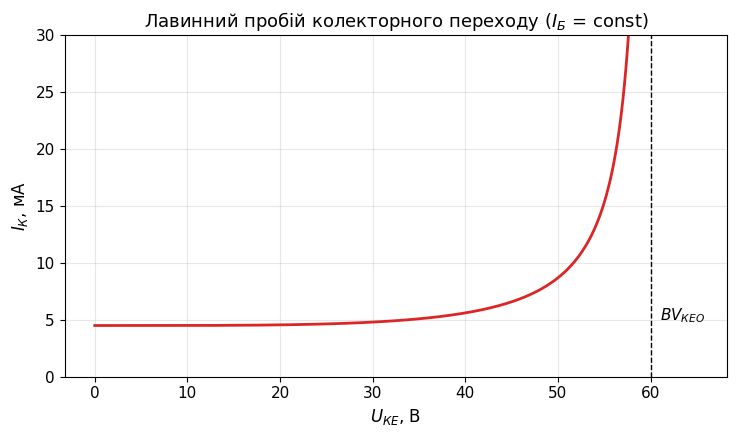

In [6]:
U = np.linspace(0, 65, 400)
BV, n, Ib = 60.0, 4, 30e-6
beta = 150
M = 1.0 / (1.0 - np.clip(U / BV, 0, 0.995) ** n)
Ic = beta * Ib * M * 1000  # мА
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(U, Ic, color='#dc2626')
ax.axvline(BV, color='k', ls='--', lw=1)
ax.text(BV + 1, ax.get_ylim()[1]*0.6 if False else 5, '$BV_{КЕО}$', color='k')
ax.set_ylim(0, 30)
ax.set_xlabel('$U_{КЕ}$, В')
ax.set_ylabel('$I_К$, мА')
ax.set_title('Лавинний пробій колекторного переходу ($I_Б$ = const)')
plt.tight_layout()
plt.show()


### ⚠️ Типова помилка

<div style="background-color: #fef2f2; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #dc2626; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Не плутайте $BV_{КБО}$ (пробій переходу колектор–база при **розімкненому емітері**, найбільше допустиме значення) з $BV_{КЕО}$ (пробій колектор–емітер при **розімкненій базі**, суттєво менше значення через підсилення лавинного струму коефіцієнтом $\beta$). У довідниках завжди перевіряйте, до якої саме схеми вимірювання належить наведена гранична напруга — плутанина цих величин при проєктуванні призводить до пробою "справного за паспортом" транзистора вже за номінальної напруги живлення.

</div>


## Залежність коефіцієнта підсилення біполярного транзистора від режиму роботи <a class="anchor" id="bjt-gain-dependence"></a>

Коефіцієнт передачі струму бази $\beta = I_к/I_б$ **не є сталою величиною** — він суттєво залежить від струму колектора, напруги $U_{КЕ}$ та температури.

**Залежність від струму колектора $I_к$** має характерний "дзвоноподібний" вигляд:
- **при малих $I_к$** $\beta$ падає через переважання рекомбінації носіїв у збідненій області емітерного переходу (складова струму бази з коефіцієнтом неідеальності $n_e \approx 2$ зростає відносно швидше за дифузійну складову);
- **у середньому діапазоні** струмів $\beta$ максимальний і найстабільніший — саме тут рекомендують вибирати робочу точку підсилювальних каскадів;
- **при великих $I_к$** $\beta$ знову падає через ефект **високого рівня інжекції** (ефект Вебстера: концентрація інжектованих неосновних носіїв стає порівнянною з концентрацією основних домішкових носіїв бази, що знижує ефективність інжекції) та ефект **розширення бази Кірка** (при великих густинах струму рухома область просторового заряду колекторного переходу зміщується углиб слаболегованого колектора, ефективно збільшуючи товщину бази).

**Залежність від напруги $U_{КЕ}$** — слабка, через ефект Ерлі (модуляція товщини бази зворотним зміщенням колекторного переходу): зі зростанням $U_{КЕ}$ ефективна товщина бази трохи зменшується, і $\beta$ незначно зростає.

**Залежність від температури** — $\beta$ зростає з температурою (приблизно на 0.5–1 % на 1 °C), оскільки зростає дифузійна довжина неосновних носіїв і зменшується ширина забороненої зони (більша концентрація власних носіїв). Це створює позитивний зворотний зв'язок: нагрів → зростання $\beta$ і $I_к$ → додаткове тепловиділення — потенційне джерело **теплового runaway (теплової нестабільності)**, яке необхідно враховувати при проєктуванні кіл термостабілізації робочої точки.

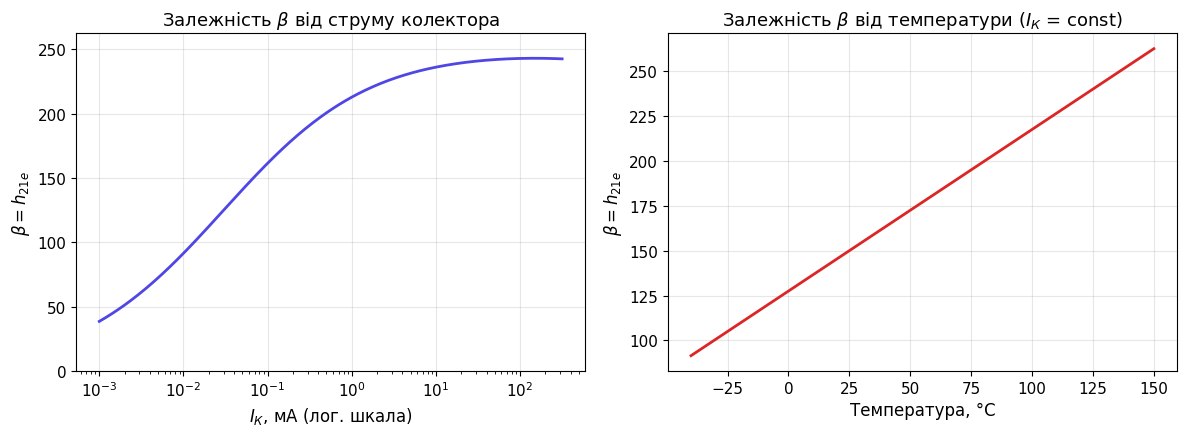

In [7]:
Ic = np.logspace(-6, -0.5, 300)  # А, лог. шкала
beta_max = 250
low = (Ic / 3e-5) ** 0.5
high = (Ic / 0.15) ** 1.0
beta = beta_max * low / (1 + low + high)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].semilogx(Ic * 1000, beta, color='#4f46e5')
axes[0].set_xlabel('$I_К$, мА (лог. шкала)')
axes[0].set_ylabel('$\\beta = h_{21e}$')
axes[0].set_title('Залежність $\\beta$ від струму колектора')
axes[0].set_ylim(0, beta_max * 1.05)

T = np.linspace(-40, 150, 200)
beta25 = 150
beta_T = beta25 * (1 + 0.006 * (T - 25))
axes[1].plot(T, beta_T, color='#dc2626')
axes[1].set_xlabel('Температура, °C')
axes[1].set_ylabel('$\\beta = h_{21e}$')
axes[1].set_title('Залежність $\\beta$ від температури ($I_К$ = const)')
plt.tight_layout()
plt.show()


## Частотні характеристики біполярного транзистора <a class="anchor" id="bjt-frequency"></a>

На високих частотах підсилювальні властивості транзистора обмежуються **інерційністю** фізичних процесів: часом дифузії носіїв через базу та перезарядом бар'єрних ємностей переходів. Малосигнальна еквівалентна схема (гібридна П-подібна модель) вводить:
- $C_{бе}$ — сумарна ємність емітерного переходу (бар'єрна + дифузійна, домінує дифузійна);
- $C_{бк}$ — бар'єрна ємність колекторного переходу (значно менша за $C_{бе}$, але критично впливає через ефект Міллера);
- $r_б, r_е, r_к$ — диференціальні опори областей;
- $g_m = I_к/\varphi_T$ — крутизна (транскондуктанс).

**Гранична частота коефіцієнта $\beta$** $f_\beta$ — частота, на якій модуль $|h_{21e}|$ зменшується у $\sqrt2$ разів (на 3 дБ) відносно низькочастотного значення $\beta_0$ через одно-полюсний спад:
$$|h_{21e}(f)| = \dfrac{\beta_0}{\sqrt{1+(f/f_\beta)^2}}.$$

**Гранична частота підсилення** $f_T$ (transition frequency) — частота, на якій $|h_{21e}| = 1$ (втрачається підсилення струму). Оскільки спад іде зі схилом 20 дБ/дек, $f_T \approx \beta_0 \cdot f_\beta$ — стандартний параметр із довідників, що характеризує швидкодію транзистора.

**Ефект Міллера.** У схемі СЕ ємність $C_{бк}$, увімкнена між входом (базою) і виходом (колектором) з інвертованим і підсиленим сигналом, еквівалентно "трансформується" у вхідне коло зі значно більшим значенням:
$$C_{вх,Міллера} = C_{бк}(1+|K_U|),$$
що суттєво звужує смугу пропускання каскаду СЕ порівняно зі схемами СБ чи СК, де ефект Міллера відсутній або значно слабший — тому широкосмугові й НВЧ каскади часто будують за схемою СБ або каскодною схемою (СЕ+СБ), яка усуває ефект Міллера.

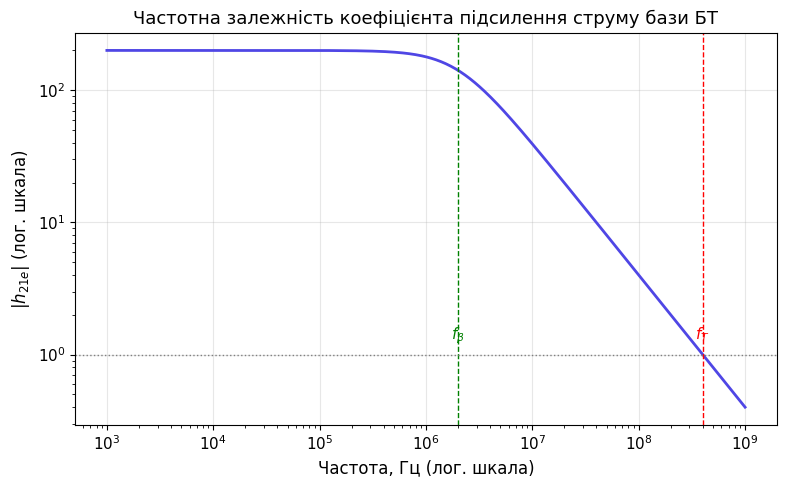

In [8]:
f = np.logspace(3, 9, 400)
beta0, f_beta = 200.0, 2e6
h21e = beta0 / np.sqrt(1 + (f / f_beta) ** 2)
f_T = beta0 * f_beta

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(f, h21e, color='#4f46e5', lw=2)
ax.axvline(f_beta, color='green', ls='--', lw=1)
ax.axvline(f_T, color='red', ls='--', lw=1)
ax.axhline(1, color='gray', ls=':', lw=1)
ax.text(f_beta, 1.3, '$f_\\beta$', color='green', ha='center')
ax.text(f_T, 1.3, '$f_T$', color='red', ha='center')
ax.set_xlabel('Частота, Гц (лог. шкала)')
ax.set_ylabel('$|h_{21e}|$ (лог. шкала)')
ax.set_title('Частотна залежність коефіцієнта підсилення струму бази БТ')
plt.tight_layout()
plt.show()


### ⚡ Практичне застосування: Транзисторні підсилювачі та ключі

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">


Схема **СЕ** — основа більшості аналогових каскадів підсилення напруги і потужності (мікрофонні підсилювачі, підсилювачі проміжної частоти). Робота в **ключовому режимі** (перемикання насичення↔відсічка) лежить в основі цифрової логіки (TTL), драйверів реле, ШІМ-перетворювачів та інверторів, де важливі саме межі $BV_{КЕО}$ і швидкодія $f_T$/час розсмоктування заряду в базі при виході з насичення.


</div>


### ✅ Питання для самоперевірки: біполярні транзистори

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Чому струм колектора майже дорівнює струму емітера, хоча керує транзистором струм бази?</summary>

> **Відповідь:** Тому що база виготовляється тонкою і слаболегованою: майже всі носії, інжектовані емітером, дифундують крізь неї без рекомбінації і екстрагуються полем зворотно зміщеного колекторного переходу. Лише малий відсоток (одиниці відсотків) рекомбінує в базі, формуючи $I_б$.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Чим схема СЕ принципово відрізняється від СБ і СК за підсилювальними властивостями?</summary>

> **Відповідь:** СЕ — єдина схема, що одночасно підсилює і струм ($K_I\approx\beta$), і напругу, тому дає максимальне підсилення потужності; СБ підсилює лише напругу ($K_I\approx1$), СК — лише струм ($K_U\approx1$).

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Чому $BV_{КЕО}$ істотно менше за $BV_{КБО}$?</summary>

> **Відповідь:** Бо при розімкненій базі лавинно генеровані носії колекторного переходу відіграють роль додаткового струму бази, який підсилюється транзистором у $(\beta+1)$ разів — пробій розвивається лавиноподібно вже при значно нижчій зовнішній напрузі.

</details>

---


### 🎯 Мета вивчення розділу: Польові транзистори з керуючим p-n переходом

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Пояснювати структуру і принцип дії JFET
> - Описувати явище перекриття (пінч-офф) каналу зворотно зміщеним затвором
> - Розрізняти n-канальні та p-канальні JFET

</div>


# Польові транзистори з керуючим p-n переходом. Структура, принцип роботи та різновиди <a class="anchor" id="jfet-basics"></a>

**Польовий транзистор (ПТ)** — уніполярний прилад: струм переносять носії лише **одного** знаку (основні носії каналу), а керування здійснюється **електричним полем**, а не струмом керуючого електрода, як у БТ. Головна перевага — надзвичайно високий вхідний опір (керуючий електрод практично не споживає струму в статичному режимі).

**Структура JFET (n-канальний).** Це напівпровідниковий брусок n-типу (**канал**) з омічними контактами на кінцях — **витік (S, source)** і **стік (D, drain)**, з обох боків якого сформовані сильнолеговані області p-типу — **затвор (G, gate)**, електрично з'єднані між собою. Між затвором і каналом утворюється p-n перехід.

**Принцип дії.** Якщо подати на затвор відносно витоку зворотну (для n-каналу — від'ємну) напругу $U_{ЗВ}$, область просторового заряду p-n переходу розширюється **вглиб каналу**, звужуючи його струмопровідний переріз і збільшуючи опір каналу. Оскільки падіння напруги вздовж каналу від струму стоку $I_с$ додається до зовнішньої напруги затвор–канал, ОПЗ несиметрично ширша біля стоку, ніж біля витоку. При достатньо великій напрузі стік–витік $U_{СВ}$ (або достатньо від'ємній $U_{ЗВ}$) обидві збіднені області змикаються біля стокового кінця — настає **перекриття (пінч-офф)** каналу, після чого струм стоку практично перестає зростати зі збільшенням $U_{СВ}$ (входить у режим насичення).

Напруга, за якої канал повністю перекривається при $U_{СВ}=0$, називається **напругою відсічки** $U_{відс}$ (позначається також $V_p$, pinch-off voltage); для n-каналу вона від'ємна.

**Різновиди:** n-канальні та p-канальні JFET (у p-канальних усі полярності протилежні); за конструкцією — з площинним чи планарним p-n переходом.

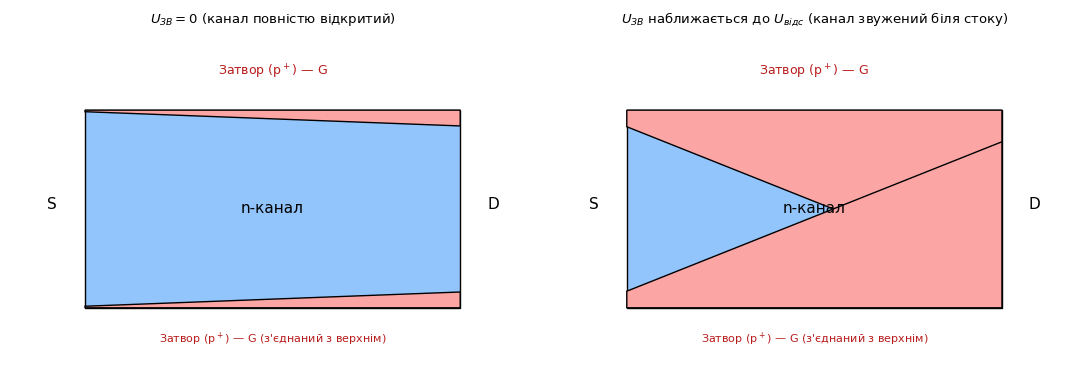

In [9]:
def draw_jfet_structure():
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    titles = ['$U_{ЗВ} = 0$ (канал повністю відкритий)', '$U_{ЗВ}$ наближається до $U_{відс}$ (канал звужений біля стоку)']
    pinches = [0.04, 0.42]
    for ax, title, p in zip(axes, titles, pinches):
        ax.add_patch(plt.Rectangle((0, 0), 4, 2, facecolor='#93c5fd', edgecolor='k'))
        ax.add_patch(plt.Polygon([[0, 2], [4, 2], [4, 2 - p * 4], [0, 2 - p * 0.4]], closed=True,
                                  facecolor='#fca5a5', edgecolor='k'))
        ax.add_patch(plt.Polygon([[0, 0], [4, 0], [4, p * 4], [0, p * 0.4]], closed=True,
                                  facecolor='#fca5a5', edgecolor='k'))
        ax.text(2, 1, 'n-канал', ha='center', va='center')
        ax.text(-0.35, 1, 'S', ha='center', fontsize=11)
        ax.text(4.35, 1, 'D', ha='center', fontsize=11)
        ax.text(2, 2.35, 'Затвор (p$^+$) — G', ha='center', color='#b91c1c', fontsize=9)
        ax.text(2, -0.35, 'Затвор (p$^+$) — G (з'"'"'єднаний з верхнім)', ha='center', color='#b91c1c', fontsize=8)
        ax.set_xlim(-0.8, 4.8)
        ax.set_ylim(-0.7, 2.8)
        ax.axis('off')
        ax.set_title(title, fontsize=9.5)
    plt.tight_layout()
    plt.show()

draw_jfet_structure()


### 💡 Цікаво знати

<div style="background-color: #eff6ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #2563eb; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Ідею польового транзистора з керуючим переходом теоретично описав ще **Вільям Шоклі** у 1952 р. (стаття *"A Unipolar Field-Effect Transistor"*) — за кілька років до появи практичних площинних JFET. Цікаво, що концепція керування провідністю каналу поперечним електричним полем була запатентована ще раніше — **Юліусом Едгаром Лілієнфельдом** у 1926 р. і **Оскаром Хейлем** у 1934 р., задовго до появи технологій, здатних реалізувати такий прилад практично.

</div>


## Статичні характеристики польового транзистора з p-n переходом <a class="anchor" id="jfet-characteristics"></a>

**Вихідна (стокова) характеристика** $I_с = f(U_{СВ})$ при $U_{ЗВ} = \text{const}$ має три ділянки:
- **крута (омічна/тріодна) ділянка** — при малих $U_{СВ}$ канал ще не перекритий, транзистор поводиться як керований напругою затвора резистор;
- **пологу ділянку насичення** — після перекриття каналу біля стоку струм майже не залежить від $U_{СВ}$:
$$I_с = I_{DSS}\left(1-\dfrac{U_{ЗВ}}{U_{відс}}\right)^2,$$
де $I_{DSS}$ — струм стоку при $U_{ЗВ}=0$ (максимально можливий);
- **ділянку пробою** — при великих $U_{СВ}$ настає лавинний пробій зворотно зміщеного переходу затвор–стік.

**Прохідна (передавальна) характеристика** $I_с = f(U_{ЗВ})$ при $U_{СВ}=\text{const}$ (у насиченні) — та сама квадратична (параболічна) залежність, зображена вище як функція $U_{ЗВ}$; вона наочно показує керуючу дію затвора: при $U_{ЗВ}=0$ струм максимальний $I_{DSS}$, при $U_{ЗВ}=U_{відс}$ струм спадає до нуля.

2026-09-21 10:49:31,438 - PySpice.Spice.NgSpice.Shared.NgSpiceShared._send_char - WARNING - Using SPARSE 1.3 as Direct Linear Solver


2026-09-21 10:49:31,444 - PySpice.Spice.NgSpice.Shared.NgSpiceShared._send_char - WARNING - Using SPARSE 1.3 as Direct Linear Solver


2026-09-21 10:49:31,448 - PySpice.Spice.NgSpice.Shared.NgSpiceShared._send_char - WARNING - Using SPARSE 1.3 as Direct Linear Solver


2026-09-21 10:49:31,453 - PySpice.Spice.NgSpice.Shared.NgSpiceShared._send_char - WARNING - Using SPARSE 1.3 as Direct Linear Solver


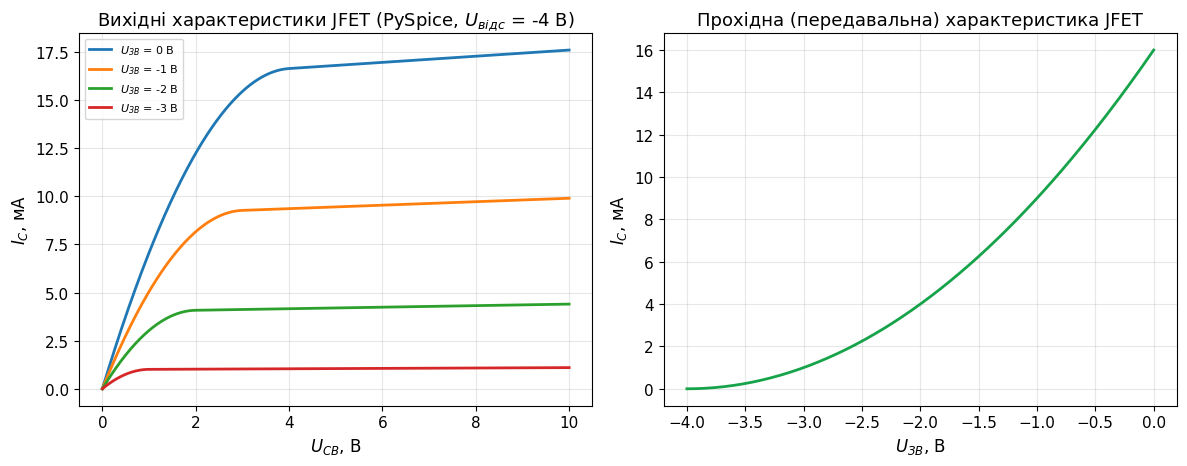

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

for vgs in [0, -1, -2, -3]:
    circuit = Circuit('JFET output characteristics')
    circuit.model('njf1', 'NJF', vto=-4, beta=1e-3, lambda_=0.01)
    circuit.V('GS', 'g', circuit.gnd, vgs @ u_V)
    circuit.V('DS', 'd', circuit.gnd, 0 @ u_V)
    circuit.JFET(1, 'd', 'g', circuit.gnd, model='njf1')
    simulator = circuit.simulator(temperature=25, nominal_temperature=25)
    analysis = simulator.dc(VDS=slice(0, 10, 0.02))
    vds = np.array(analysis['d'])
    id_ = -np.array(analysis['VDS']) * 1000
    axes[0].plot(vds, id_, label=f'$U_{{ЗВ}}$ = {vgs} В')

axes[0].set_xlabel('$U_{СВ}$, В')
axes[0].set_ylabel('$I_С$, мА')
axes[0].set_title('Вихідні характеристики JFET (PySpice, $U_{відс}$ = -4 В)')
axes[0].legend(fontsize=8)

Vp, Idss = -4.0, 16.0
Ugs = np.linspace(Vp, 0, 200)
Ic_transfer = Idss * (1 - Ugs / Vp) ** 2
axes[1].plot(Ugs, Ic_transfer, color='#16a34a')
axes[1].set_xlabel('$U_{ЗВ}$, В')
axes[1].set_ylabel('$I_С$, мА')
axes[1].set_title('Прохідна (передавальна) характеристика JFET')
plt.tight_layout()
plt.show()


### ⚠️ Типова помилка

<div style="background-color: #fef2f2; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #dc2626; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Не забувайте про **знак** напруги відсічки: для n-канального JFET $U_{відс}$ (і робочі $U_{ЗВ}$) — **від'ємні** величини, для p-канального — додатні. У формулі $I_с=I_{DSS}(1-U_{ЗВ}/U_{відс})^2$ обидва доданки мають узгоджений знак — типова помилка на іспиті: підставити модуль $|U_{відс}|$ замість напруги зі знаком і отримати хибний результат поза межами $[0, I_{DSS}]$.

</div>


---


### 🎯 Мета вивчення розділу: МДН-транзистори

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Пояснювати структуру МДН-транзистора з ізольованим затвором
> - Описувати механізм індукування провідного каналу полем затвора
> - Розрізняти транзистори зі вбудованим і з індукованим каналом

</div>


## Принцип дії польового транзистора з ізольованим затвором і індукованим каналом <a class="anchor" id="mosfet-enhancement"></a>

**МДН-транзистор** (метал–діелектрик–напівпровідник, англ. MOSFET) відрізняється від JFET тим, що затвор **електрично ізольований** від каналу тонким шаром діелектрика (найчастіше — оксиду кремнію $SiO_2$), а не утворює з ним p-n перехід. Це забезпечує ще вищий вхідний опір (десятки МОм – одиниці ГОм) і принципово інший механізм керування.

**Структура (n-канальний МДН з індукованим каналом):** на підкладці (basi) p-типу формують дві сильнолеговані області n$^+$ — **витік** і **стік**. Простір між ними покривають тонким шаром оксиду, поверх якого наносять металевий (чи полікремнієвий) електрод — **затвор**. У вихідному стані ($U_{ЗВ}=0$) між витоком і стоком немає провідного n-каналу — є лише два зустрічно ввімкнені p-n переходи, тому струм стоку практично нульовий незалежно від полярності $U_{СВ}$.

**Механізм індукування каналу.** Коли на затвор подають напругу $U_{ЗВ}>0$ (для n-канального МДН), електричне поле через діелектрик відштовхує основні носії підкладки (дірки) від межі розділу та притягує неосновні (електрони), які накопичуються під оксидом, утворюючи тонкий інверсійний шар n-типу — **індукований канал**, що з'єднує витік зі стоком. Мінімальна напруга, за якої канал з'являється, називається **пороговою напругою** $U_{пор}$ (threshold voltage, $V_T$). При $U_{ЗВ} > U_{пор}$ провідність каналу, а отже і струм стоку, зростає з ростом $U_{ЗВ}$.

Такі транзистори називають приладами **збагачення (enhancement mode)**: канал відсутній при нульовій напрузі затвора і "збагачується" (з'являється й посилюється) під дією керуючої напруги — на відміну від МДН-транзисторів **зі вбудованим каналом (depletion mode)**, у яких провідний канал технологічно створений заздалегідь і при $U_{ЗВ}=0$ вже існує, а керуюча напруга може як збагачувати, так і збіднювати його.

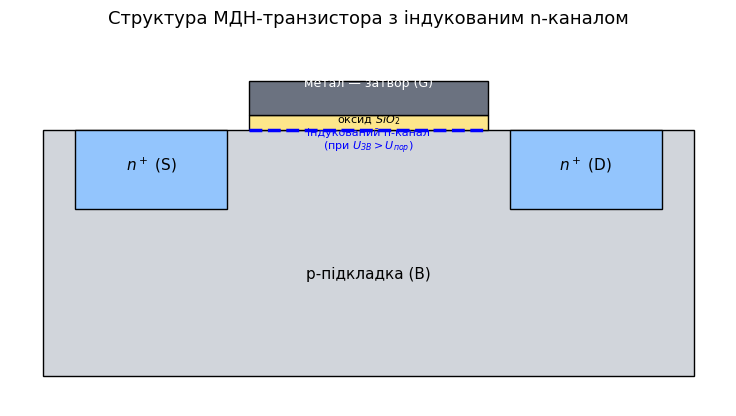

In [11]:
def draw_mosfet_structure():
    fig, ax = plt.subplots(figsize=(7.5, 4.3))
    ax.add_patch(plt.Rectangle((0, 0), 6, 2.5, facecolor='#d1d5db', edgecolor='k'))
    ax.add_patch(plt.Rectangle((0.3, 1.7), 1.4, 0.8, facecolor='#93c5fd', edgecolor='k'))
    ax.add_patch(plt.Rectangle((4.3, 1.7), 1.4, 0.8, facecolor='#93c5fd', edgecolor='k'))
    ax.add_patch(plt.Rectangle((1.9, 2.5), 2.2, 0.15, facecolor='#fde68a', edgecolor='k'))
    ax.add_patch(plt.Rectangle((1.9, 2.65), 2.2, 0.35, facecolor='#6b7280', edgecolor='k'))
    ax.plot([1.9, 4.1], [2.5, 2.5], 'b--', lw=2.5)
    ax.text(1.0, 2.1, '$n^+$ (S)', ha='center')
    ax.text(5.0, 2.1, '$n^+$ (D)', ha='center')
    ax.text(3.0, 2.575, 'оксид $SiO_2$', ha='center', fontsize=8)
    ax.text(3.0, 2.95, 'метал — затвор (G)', ha='center', fontsize=9, color='white')
    ax.text(3.0, 1.0, 'p-підкладка (B)', ha='center')
    ax.text(3.0, 2.30, 'індукований n-канал\n(при $U_{ЗВ}>U_{пор}$)', ha='center', fontsize=8, color='blue')
    ax.set_xlim(-0.3, 6.3)
    ax.set_ylim(-0.3, 3.5)
    ax.axis('off')
    ax.set_title('Структура МДН-транзистора з індукованим n-каналом')
    plt.tight_layout()
    plt.show()

draw_mosfet_structure()


### ⚠️ Типова помилка

<div style="background-color: #fef2f2; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #dc2626; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Не плутайте МДН-транзистор **з індукованим каналом** (канал відсутній при $U_{ЗВ}=0$, з'являється лише при $|U_{ЗВ}|>|U_{пор}|$, режим *enhancement*) з МДН-транзистором **зі вбудованим каналом** (канал є вже при $U_{ЗВ}=0$, режим *depletion*, керуюча напруга лише змінює його провідність в обидва боки). На умовному позначенні їх розрізняють за виглядом лінії каналу: суцільна лінія — вбудований канал, переривчаста (штрихова) — індукований.

</div>


## Статичні характеристики польового транзистора з ізольованим затвором і індукованим каналом <a class="anchor" id="mosfet-characteristics"></a>

Аналогічно до JFET, вихідна характеристика МДН-транзистора має **тріодну (лінійну) область** і **область насичення**, розмежовані умовою $U_{СВ} = U_{ЗВ}-U_{пор}$:

**Тріодна (лінійна) область** ($U_{СВ} < U_{ЗВ}-U_{пор}$) — канал ще не перекритий біля стоку, транзистор працює як керований напругою затвора резистор:
$$I_с = k\left[(U_{ЗВ}-U_{пор})U_{СВ} - \dfrac{U_{СВ}^2}{2}\right].$$

**Область насичення** ($U_{СВ} \ge U_{ЗВ}-U_{пор}$) — канал перекритий (pinch-off) біля стокового кінця, струм практично не залежить від $U_{СВ}$ (з урахуванням модуляції довжини каналу — невеликий нахил):
$$I_с = \dfrac{k}{2}(U_{ЗВ}-U_{пор})^2 (1+\lambda U_{СВ}),$$
де $k$ — параметр крутизни технологічного процесу, $\lambda$ — коефіцієнт модуляції довжини каналу.

**Прохідна характеристика** $I_с=f(U_{ЗВ})$ у насиченні — та сама парабола, що "стартує" від порогової напруги $U_{пор}$ (на відміну від JFET, де вона стартує від нуля і спадає до $U_{відс}$).

2026-09-21 10:49:32,146 - PySpice.Spice.NgSpice.Shared.NgSpiceShared._send_char - WARNING - Using SPARSE 1.3 as Direct Linear Solver


2026-09-21 10:49:32,153 - PySpice.Spice.NgSpice.Shared.NgSpiceShared._send_char - WARNING - Using SPARSE 1.3 as Direct Linear Solver


2026-09-21 10:49:32,158 - PySpice.Spice.NgSpice.Shared.NgSpiceShared._send_char - WARNING - Using SPARSE 1.3 as Direct Linear Solver


2026-09-21 10:49:32,164 - PySpice.Spice.NgSpice.Shared.NgSpiceShared._send_char - WARNING - Using SPARSE 1.3 as Direct Linear Solver


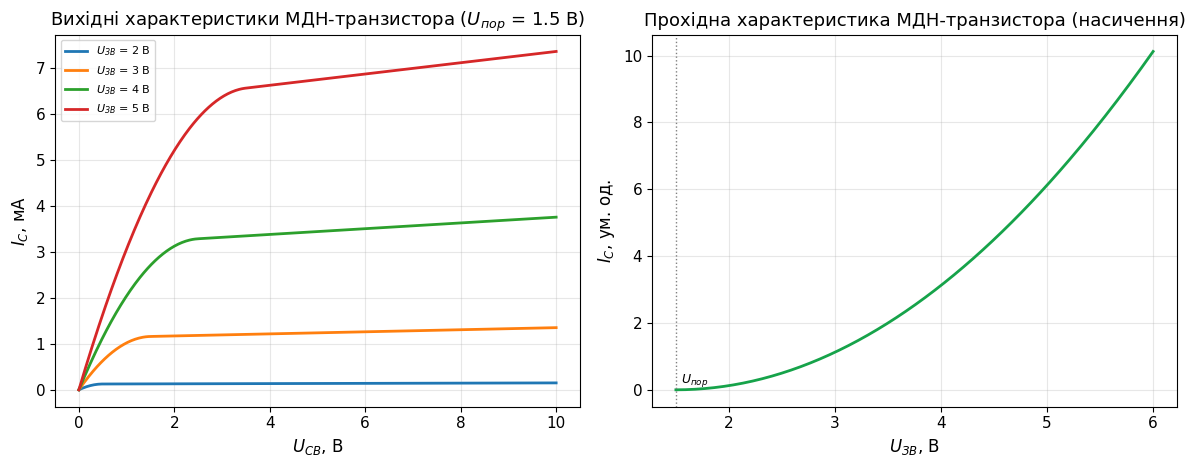

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

for vgs in [2, 3, 4, 5]:
    circuit = Circuit('MOSFET output characteristics')
    circuit.model('nmos1', 'NMOS', level=1, vto=1.5, kp=1e-3, lambda_=0.02)
    circuit.V('GS', 'g', circuit.gnd, vgs @ u_V)
    circuit.V('DS', 'd', circuit.gnd, 0 @ u_V)
    circuit.MOSFET(1, 'd', 'g', circuit.gnd, circuit.gnd, model='nmos1')
    simulator = circuit.simulator(temperature=25, nominal_temperature=25)
    analysis = simulator.dc(VDS=slice(0, 10, 0.02))
    vds = np.array(analysis['d'])
    id_ = -np.array(analysis['VDS']) * 1000
    axes[0].plot(vds, id_, label=f'$U_{{ЗВ}}$ = {vgs} В')

axes[0].set_xlabel('$U_{СВ}$, В')
axes[0].set_ylabel('$I_С$, мА')
axes[0].set_title('Вихідні характеристики МДН-транзистора ($U_{пор}$ = 1.5 В)')
axes[0].legend(fontsize=8)

Vt, k = 1.5, 1.0
Vgs = np.linspace(Vt, 6, 200)
Id = k / 2 * (Vgs - Vt) ** 2
axes[1].plot(Vgs, Id, color='#16a34a')
axes[1].axvline(Vt, color='gray', ls=':', lw=1)
axes[1].text(Vt + 0.05, 0.2, '$U_{пор}$', fontsize=9)
axes[1].set_xlabel('$U_{ЗВ}$, В')
axes[1].set_ylabel('$I_С$, ум. од.')
axes[1].set_title('Прохідна характеристика МДН-транзистора (насичення)')
plt.tight_layout()
plt.show()


## Частотні властивості польових транзисторів <a class="anchor" id="fet-frequency"></a>

Швидкодія ПТ визначається зарядом ємностей затвор–канал через диференціальний опір каналу і зовнішніх кіл. Основні паразитні ємності: $C_{зв}$ (затвор–витік), $C_{зс}$ (затвор–стік, аналог $C_{бк}$ БТ — теж дає ефект Міллера в схемі зі спільним витоком/джерелом), $C_{сп}$ (стік–підкладка).

**Крутизна (транскондуктанс)** — головний "підсилювальний" параметр ПТ:
$$g_m = \dfrac{\partial I_с}{\partial U_{ЗВ}} = k(U_{ЗВ}-U_{пор}) \ \text{(МДН, насичення)}, \qquad g_m = \dfrac{2 I_{DSS}}{|U_{відс}|}\left(1-\dfrac{U_{ЗВ}}{U_{відс}}\right) \ \text{(JFET)}.$$

**Гранична частота** $f_T$ (на якій коефіцієнт передачі струму затвор→канал стає рівним 1):
$$f_T = \dfrac{g_m}{2\pi (C_{зв}+C_{зс})}.$$

Через відсутність інжекції неосновних носіїв (немає дифузійної затримки, як у базі БТ) ПТ на однакових технологічних нормах можуть мати вищу швидкодію, проте на практиці $f_T$ сучасних біполярних НВЧ-транзисторів і МДН-транзисторів — величини одного порядку, а перевага того чи іншого типу залежить від конкретного технологічного процесу. JFET традиційно поступаються МДН за $f_T$ через більшу площу і ємність керуючого p-n переходу, але виграють за рівнем власних шумів на низьких частотах.

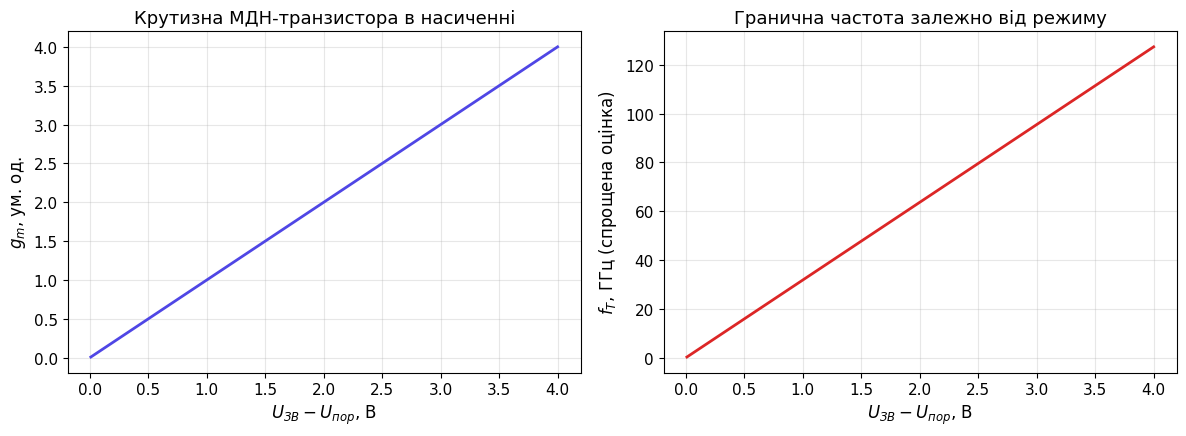

In [13]:
Vt, k = 1.5, 1.0
Cgs_Cgd = 5e-12  # Ф, спрощено вважаємо сталою сумою ємностей
Vov = np.linspace(0.01, 4, 200)  # перевищення порогу Uзв - Uпор
gm = k * Vov
fT = gm / (2 * np.pi * Cgs_Cgd) / 1e9  # ГГц

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(Vov, gm, color='#4f46e5')
axes[0].set_xlabel('$U_{ЗВ}-U_{пор}$, В')
axes[0].set_ylabel('$g_m$, ум. од.')
axes[0].set_title('Крутизна МДН-транзистора в насиченні')

axes[1].plot(Vov, fT, color='#dc2626')
axes[1].set_xlabel('$U_{ЗВ}-U_{пор}$, В')
axes[1].set_ylabel('$f_T$, ГГц (спрощена оцінка)')
axes[1].set_title('Гранична частота залежно від режиму')
plt.tight_layout()
plt.show()


## Робота польового транзистора на імпульс <a class="anchor" id="fet-pulse"></a>

У ключових (імпульсних) схемах ПТ комутують за прямокутним сигналом на затворі. Через ізольований затвор вхід поводиться як **конденсатор** ($C_{вх}=C_{зв}+C_{зс}(1+K_U)$ з урахуванням ефекту Міллера), який керуюче джерело заряджає/розряджає через опір затворового кола $R_г$ (внутрішній опір драйвера + послідовний резистор). Це визначає характерні часові інтервали перемикання:

- **час затримки ввімкнення** $t_{d(on)}$ — час заряду $C_{вх}$ від нуля до порогової напруги $U_{пор}$, протягом якого канал ще не провідний;
- **час наростання** $t_r$ — час заряду від $U_{пор}$ до напруги, за якої транзистор входить у тріодну область (повне відкриття), протягом якого струм стоку наростає;
- **плато Міллера** — під час перемикання стоку ємність $C_{зс}$ перезаряджається великим стрибком напруги $U_{СВ}$, тимчасово "поглинаючи" струм заряду і практично зупиняючи зростання $U_{ЗВ}$ — на графіці $U_{ЗВ}(t)$ це виглядає як пологе горизонтальне плато;
- **час затримки вимкнення** $t_{d(off)}$ і **час спаду** $t_f$ — аналогічні інтервали при розрядці $C_{вх}$ через $R_г$ до нуля.

Швидкодія ключа прямо пропорційна $R_г C_{вх}$: чим менший опір драйвера затвора і менша вхідна ємність, тим швидше перемикання і менші динамічні втрати потужності $P \sim f_{комут} C_{вх} U^2$ — тому в потужній силовій електроніці застосовують спеціалізовані драйвери затворів з малим вихідним опором.

2026-09-21 10:49:33,117 - PySpice.Spice.NgSpice.Shared.NgSpiceShared._send_char - WARNING - Using SPARSE 1.3 as Direct Linear Solver


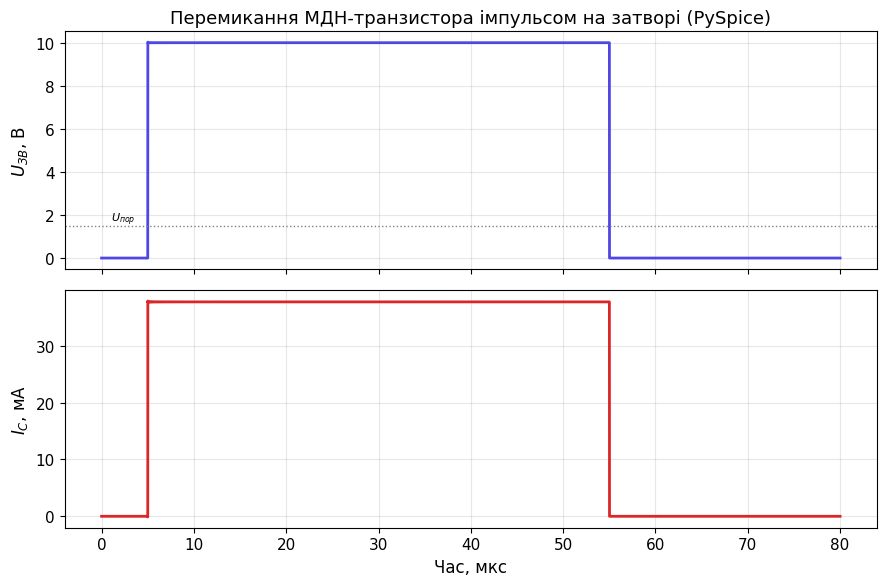

In [14]:
circuit = Circuit('MOSFET switching transient')
circuit.model('nmos1', 'NMOS', level=1, vto=1.5, kp=1e-3, lambda_=0.02, cgso=1e-9, cgdo=1e-9)
source = circuit.PulseVoltageSource('pulse', 'gin', circuit.gnd,
                                     initial_value=0 @ u_V, pulsed_value=10 @ u_V,
                                     pulse_width=50 @ u_us, period=100 @ u_us,
                                     delay_time=5 @ u_us, rise_time=10 @ u_ns, fall_time=10 @ u_ns)
circuit.R('g', 'gin', 'g', 1 @ u_kΩ)
circuit.V('DD', 'vdd', circuit.gnd, 10 @ u_V)
circuit.R('D', 'vdd', 'd', 100 @ u_Ω)
circuit.MOSFET(1, 'd', 'g', circuit.gnd, circuit.gnd, model='nmos1')

simulator = circuit.simulator(temperature=25, nominal_temperature=25)
analysis = simulator.transient(step_time=50 @ u_ns, end_time=80 @ u_us)

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot(np.array(analysis.time) * 1e6, np.array(analysis['g']), color='#4f46e5')
axes[0].axhline(1.5, color='gray', ls=':', lw=1)
axes[0].text(1, 1.7, '$U_{пор}$', fontsize=8)
axes[0].set_ylabel('$U_{ЗВ}$, В')
axes[0].set_title('Перемикання МДН-транзистора імпульсом на затворі (PySpice)')

Id = (10 - np.array(analysis['d'])) / 100 * 1000  # мА, через Rd=100 Ом
axes[1].plot(np.array(analysis.time) * 1e6, Id, color='#dc2626')
axes[1].set_xlabel('Час, мкс')
axes[1].set_ylabel('$I_С$, мА')
plt.tight_layout()
plt.show()


### 💡 Цікаво знати

<div style="background-color: #eff6ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #2563eb; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Перший практичний МДН-транзистор створили **Мохамед Атталла** і **Давон Канг** у Bell Labs у 1959–1960 рр., спираючись на технологію термічного оксидування кремнію. Попри теоретичне випередження на десятиліття (патенти Лілієнфельда 1920-х), саме якісний діелектричний шар $SiO_2$ з малою густиною поверхневих станів виявився "відсутньою ланкою", яка й уможливила практичну реалізацію ізольованого затвора.

</div>


### ⚡ Практичне застосування: Потужні ключі на МДН-транзисторах

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">


Завдяки високому вхідному опору, відсутності накопичення неосновних носіїв (немає часу розсмоктування заряду бази, як у БТ у насиченні) та малим динамічним втратам, силові МДН-транзистори — основний елемент імпульсних джерел живлення (SMPS), драйверів двигунів, інверторів сонячних панелей і зарядних пристроїв, що працюють на частотах від десятків кГц до одиниць МГц.


</div>


### ✅ Питання для самоперевірки: польові транзистори

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> У чому принципова відмінність керування JFET від МДН-транзистора?</summary>

> **Відповідь:** У JFET керуючий електрод утворює з каналом p-n перехід, зворотне зміщення якого звужує канал розширенням області просторового заряду. У МДН-транзисторі затвор ізольований діелектриком від каналу, і керування відбувається електричним полем, яке індукує (або змінює провідність вже існуючого) інверсійний шар — без будь-якого переходу і без статичного струму керування.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Чому МДН-транзистор з індукованим каналом при $U_{ЗВ}=0$ не проводить струм?</summary>

> **Відповідь:** Тому що між витоком і стоком (обидва n$^+$-типу) і p-підкладкою немає провідного шляху — є лише два зустрічно ввімкнені p-n переходи. Провідний n-канал з'являється лише тоді, коли поле затвора індукує інверсійний шар, тобто при $U_{ЗВ}>U_{пор}$.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Чому саме ємність $C_{зс}$ (аналог $C_{бк}$ БТ), а не $C_{зв}$, найбільше обмежує швидкодію ключа на польовому транзисторі?</summary>

> **Відповідь:** Через ефект Міллера: $C_{зс}$ з'єднує вхід (затвор) з виходом (стоком), на якому під час перемикання відбувається великий перепад напруги. Ця ємність перезаряджається повним розмахом $\Delta U_{СВ}$, що при увімкненому ефективному підсиленні еквівалентно суттєво більшій вхідній ємності — звідси характерне 'плато Міллера' на графіку $U_{ЗВ}(t)$.

</details>

---


### 📌 Підсумок: Біполярні транзистори проти польових транзисторів

<div style="background-color: #f0fdf4; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #16a34a; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">


| Параметр | Біполярний транзистор (БТ) | Польовий транзистор (ПТ) |
|----------|------------------------------|-----------------------------|
| Носії заряду | Обидва знаки (інжекція неосновних) | Один знак (основні носії каналу) |
| Керуючий параметр | Струм бази $I_б$ | Напруга затвора $U_{ЗВ}$ |
| Вхідний опір | Середній (кОм) | Дуже високий (МОм – ГОм, JFET; ще вищий у МДН) |
| Швидкодія / шум | Високий $f_T$, більший фліккер/дробовий шум через дифузійні процеси | Порівнянний або вищий $f_T$ (МДН), менші низькочастотні шуми (особливо JFET) |
| Термостабільність | $\beta$ і $I_к$ ростуть з температурою — ризик теплового runaway | Крутизна $g_m$ зазвичай слабко/від'ємно залежить від температури — природно стабільніший |
| Типовий режим відмови | Вторинний (тепловий) пробій | Пробій оксиду затвора (для МДН) при електростатичному розряді |

Обидва типи транзисторів залишаються взаємодоповнювальними: БТ традиційно домінують там, де важлива висока крутизна при малих напругах і НВЧ-підсилення, а ПТ (особливо потужні МДН) — там, де критичні високий вхідний опір, ключовий режим з малими динамічними втратами та термостабільність.


</div>


---

*Конспект підготовлено: Пахалюк Богдан Петрович, НУ "Чернігівська політехніка"*